# Estudo dos Ratings — data_spliting_hybrid

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

df = pd.read_csv("data_spliting_hybrid/testing.csv")

print(f"Total de registros: {len(df):,}")
print(f"Usuários únicos:    {df['userId'].nunique():,}")
print(f"Filmes únicos:      {df['movieId'].nunique():,}")

Total de registros: 30,241
Usuários únicos:    610
Filmes únicos:      6,096


## 1 — Notas médias

In [31]:
media_geral = df["rating"].mean()
mediana     = df["rating"].median()
desvio      = df["rating"].std()
minimo      = df["rating"].min()
maximo      = df["rating"].max()

print(f"Média geral:   {media_geral:.4f}")
print(f"Mediana:       {mediana:.4f}")
print(f"Desvio padrão: {desvio:.4f}")
print(f"Mínimo:        {minimo}")
print(f"Máximo:        {maximo}")

Média geral:   3.4966
Mediana:       3.5000
Desvio padrão: 1.0484
Mínimo:        0.5
Máximo:        5.0


## 2 — Distribuição de cada rating

        quantidade  percentual (%)
rating                            
0.5            438            1.45
1.0            835            2.76
1.5            539            1.78
2.0           2347            7.76
2.5           1684            5.57
3.0           5898           19.50
3.5           3930           13.00
4.0           8026           26.54
4.5           2597            8.59
5.0           3947           13.05


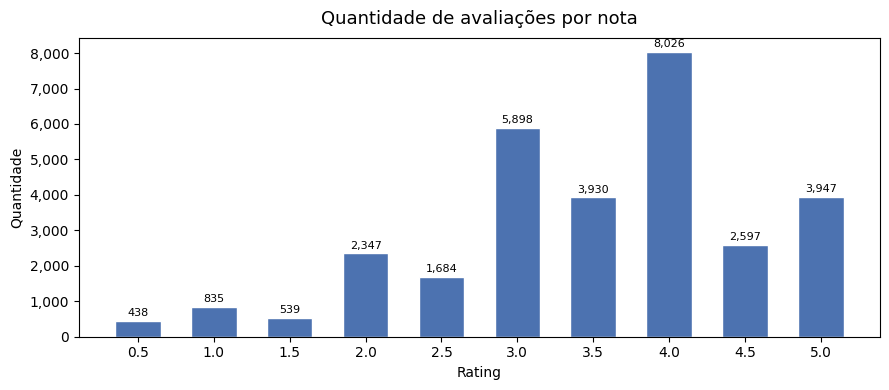

In [32]:
contagem = df["rating"].value_counts().sort_index()
pct      = (contagem / len(df) * 100).round(2)

dist = pd.DataFrame({"quantidade": contagem, "percentual (%)": pct})
print(dist.to_string())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(contagem.index.astype(str), contagem.values, width=0.6, color="#4C72B0", edgecolor="white")

for bar, val in zip(bars, contagem.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + contagem.max() * 0.01,
            f"{val:,}", ha="center", va="bottom", fontsize=8)

ax.set_title("Quantidade de avaliações por nota", fontsize=13, pad=10)
ax.set_xlabel("Rating")
ax.set_ylabel("Quantidade")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## 3 — Usuários com mais e menos filmes avaliados

=== Estatísticas gerais de avaliações por usuário ===
count    610.00
mean      49.58
std       80.82
min        6.00
25%       10.00
50%       21.00
75%       50.00
max      809.00

--- Top 15 usuários com MAIS avaliações ---
 userId  total_avaliacoes
    414               809
    599               743
    474               632
    448               559
    274               404
    610               391
     68               378
    380               365
    606               334
    288               316
    249               314
    387               308
    182               293
    307               292
    603               283

--- Top 15 usuários com MENOS avaliações ---
 userId  total_avaliacoes
     26                 6
     37                 6
     49                 6
     53                 6
     87                 6
    147                 6
    157                 6
    189                 6
    194                 6
    207                 6
    245                 6

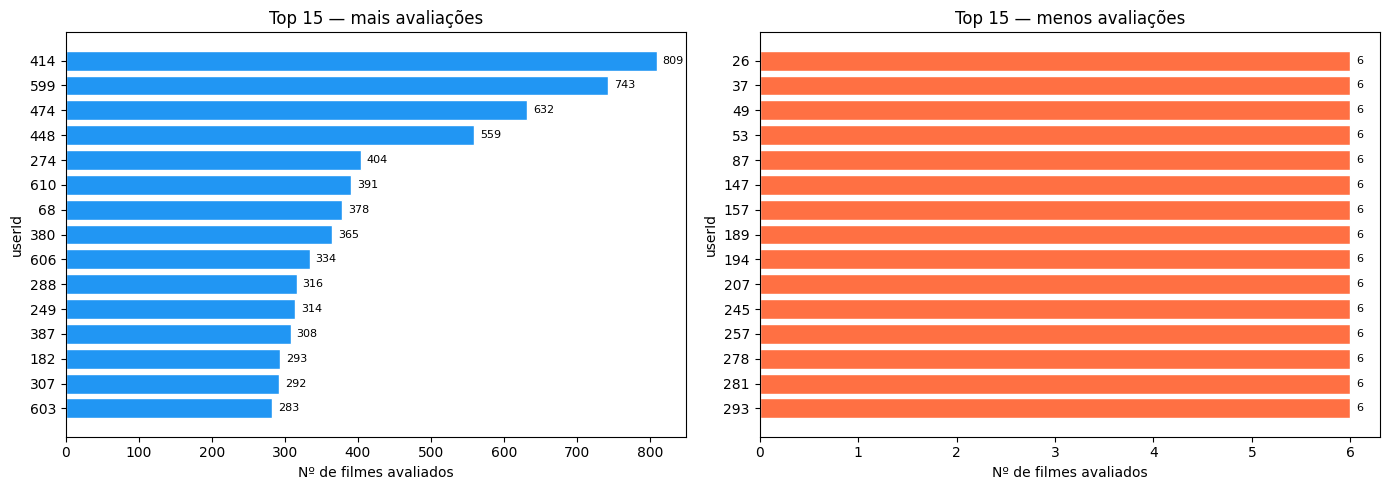

In [33]:
avaliacoes_por_usuario = df.groupby("userId")["movieId"].count().rename("total_avaliacoes")

print("=== Estatísticas gerais de avaliações por usuário ===")
print(avaliacoes_por_usuario.describe().round(2).to_string())

TOP_N = 15

top_mais = avaliacoes_por_usuario.nlargest(TOP_N).reset_index()
top_menos = avaliacoes_por_usuario.nsmallest(TOP_N).reset_index()

print(f"\n--- Top {TOP_N} usuários com MAIS avaliações ---")
print(top_mais.to_string(index=False))

print(f"\n--- Top {TOP_N} usuários com MENOS avaliações ---")
print(top_menos.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, titulo, cor in [
    (axes[0], top_mais,  f"Top {TOP_N} — mais avaliações",  "#2196F3"),
    (axes[1], top_menos, f"Top {TOP_N} — menos avaliações", "#FF7043"),
]:
    bars = ax.barh(data["userId"].astype(str), data["total_avaliacoes"], color=cor, edgecolor="white")
    ax.invert_yaxis()
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel("Nº de filmes avaliados")
    ax.set_ylabel("userId")
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    for bar, val in zip(bars, data["total_avaliacoes"]):
        ax.text(bar.get_width() + max(data["total_avaliacoes"]) * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

## 4 — Filmes com nota ≥ 4.0 por usuário

Usuários com pelo menos 1 filme nota >= 4.0: 604 / 610 (99.0%)

Estatísticas de filmes nota >= 4.0 por usuário:
count    604.00
mean      24.12
std       32.85
min        1.00
25%        6.00
50%       12.00
75%       28.25
max      384.00

--- Top 15 usuários com mais filmes nota >= 4.0 ---
 userId  filmes_nota_alta
    414               384
    474               237
    380               191
    606               171
    610               170
    603               165
    105               160
    249               146
    448               139
    182               135
    305               131
    318               128
     68               114
    477               114
    483               114


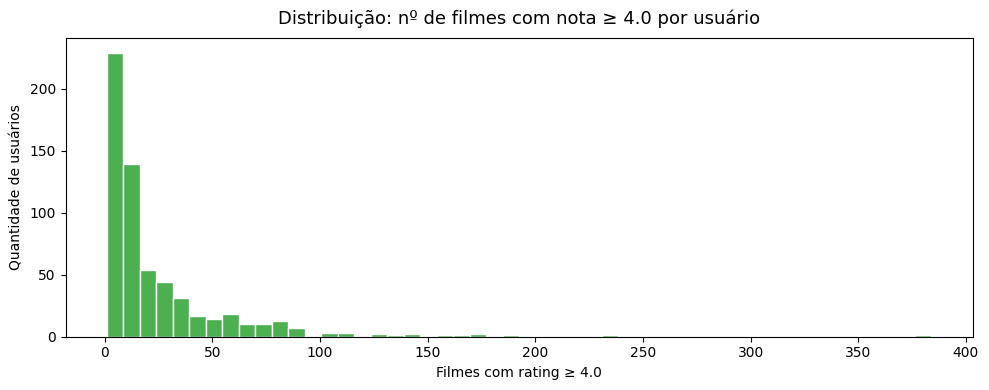

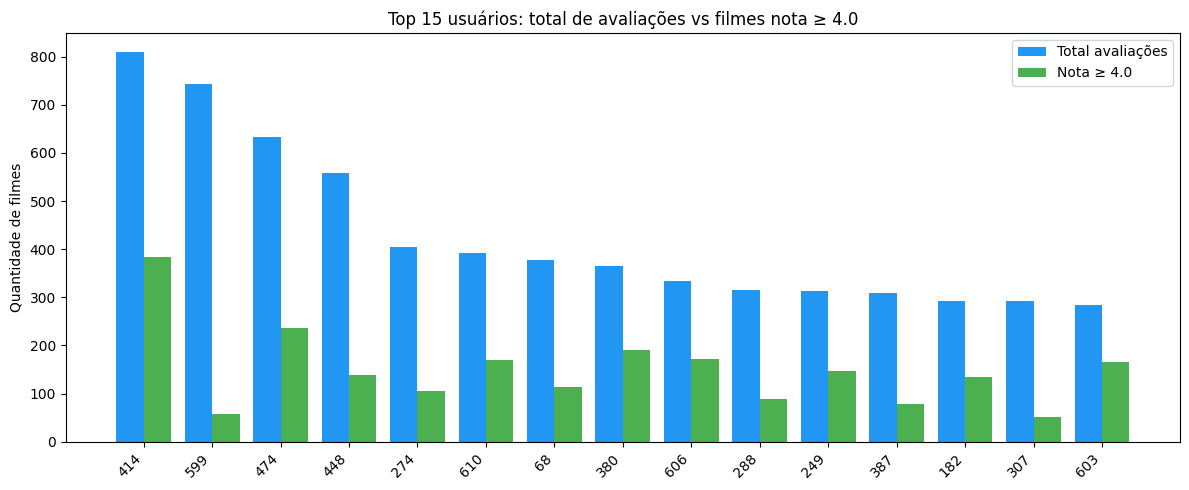


--- Percentual de filmes nota alta sobre total (top 15 usuários mais ativos) ---
 userId  total_avaliacoes  filmes_nota_alta  pct_nota_alta
    414               809               384           47.5
    599               743                57            7.7
    474               632               237           37.5
    448               559               139           24.9
    274               404               105           26.0
    610               391               170           43.5
     68               378               114           30.2
    380               365               191           52.3
    606               334               171           51.2
    288               316                89           28.2
    249               314               146           46.5
    387               308                79           25.6
    182               293               135           46.1
    307               292                51           17.5
    603               283        

In [34]:
THRESHOLD = 4.0

filmes_altos = (
    df[df["rating"] >= THRESHOLD]
    .groupby("userId")["movieId"]
    .count()
    .rename("filmes_nota_alta")
    .reset_index()
)

total_usuarios = df["userId"].nunique()
usuarios_com_alta = len(filmes_altos)
print(f"Usuários com pelo menos 1 filme nota >= {THRESHOLD}: {usuarios_com_alta:,} / {total_usuarios:,} ({usuarios_com_alta/total_usuarios*100:.1f}%)")
print(f"\nEstatísticas de filmes nota >= {THRESHOLD} por usuário:")
print(filmes_altos["filmes_nota_alta"].describe().round(2).to_string())

# Top e bottom por filmes de nota alta
top_altos  = filmes_altos.nlargest(TOP_N, "filmes_nota_alta")
top_baixos = filmes_altos.nsmallest(TOP_N, "filmes_nota_alta")

print(f"\n--- Top {TOP_N} usuários com mais filmes nota >= {THRESHOLD} ---")
print(top_altos.to_string(index=False))

# Histograma da distribuição
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(filmes_altos["filmes_nota_alta"], bins=50, color="#4CAF50", edgecolor="white")
ax.set_title(f"Distribuição: nº de filmes com nota ≥ {THRESHOLD} por usuário", fontsize=13, pad=10)
ax.set_xlabel(f"Filmes com rating ≥ {THRESHOLD}")
ax.set_ylabel("Quantidade de usuários")
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

# Comparação: total de avaliações vs filmes nota alta (top 15)
merged = (
    avaliacoes_por_usuario.reset_index()
    .merge(filmes_altos, on="userId")
    .nlargest(TOP_N, "total_avaliacoes")
)
merged["pct_nota_alta"] = (merged["filmes_nota_alta"] / merged["total_avaliacoes"] * 100).round(1)

fig, ax = plt.subplots(figsize=(12, 5))
x = range(len(merged))
width = 0.4
ax.bar([i - width/2 for i in x], merged["total_avaliacoes"], width=width, label="Total avaliações", color="#2196F3")
ax.bar([i + width/2 for i in x], merged["filmes_nota_alta"],  width=width, label=f"Nota ≥ {THRESHOLD}",        color="#4CAF50")
ax.set_xticks(list(x))
ax.set_xticklabels(merged["userId"].astype(str), rotation=45, ha="right")
ax.set_title(f"Top {TOP_N} usuários: total de avaliações vs filmes nota ≥ {THRESHOLD}", fontsize=12)
ax.set_ylabel("Quantidade de filmes")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
plt.tight_layout()
plt.show()

print("\n--- Percentual de filmes nota alta sobre total (top 15 usuários mais ativos) ---")
print(merged[["userId", "total_avaliacoes", "filmes_nota_alta", "pct_nota_alta"]].to_string(index=False))

## 5 — Usuários com menos de 10 filmes avaliados com nota ≥ 4.0

In [35]:
LIMITE = 10

# Usuários que têm pelo menos 1 avaliação >= 4.0, mas menos de LIMITE
poucos_altos = filmes_altos[filmes_altos["filmes_nota_alta"] < LIMITE].sort_values("filmes_nota_alta")

# Usuários que não têm NENHUMA avaliação >= 4.0
sem_nota_alta = (
    avaliacoes_por_usuario.reset_index()[
        ~avaliacoes_por_usuario.reset_index()["userId"].isin(filmes_altos["userId"])
    ][["userId"]]
    .assign(filmes_nota_alta=0)
)

resultado = pd.concat([sem_nota_alta, poucos_altos], ignore_index=True).sort_values("filmes_nota_alta")

print("=" * 50)
print(f"  Usuários com < {LIMITE} filmes avaliados nota >= {THRESHOLD}")
print("=" * 50)
print(f"  Total encontrado: {len(resultado)} usuários\n")

# Exibe agrupado por quantidade para ficar mais legível
for qtd, grupo in resultado.groupby("filmes_nota_alta"):
    ids = sorted(grupo["userId"].tolist())
    label = f"  {qtd} filme{'s' if qtd != 1 else ''} nota >= {THRESHOLD}"
    print(f"{label}  ({len(ids)} usuários)")
    print(f"    {ids}")
    print()

print("=" * 50)

  Usuários com < 10 filmes avaliados nota >= 4.0
  Total encontrado: 255 usuários

  0 filmes nota >= 4.0  (6 usuários)
    [54, 150, 214, 293, 333, 442]

  1 filme nota >= 4.0  (9 usuários)
    [127, 163, 194, 207, 257, 311, 394, 496, 535]

  2 filmes nota >= 4.0  (23 usuários)
    [26, 36, 37, 81, 145, 158, 242, 245, 281, 289, 299, 335, 431, 468, 478, 481, 507, 508, 529, 545, 549, 575, 576]

  3 filmes nota >= 4.0  (22 usuários)
    [35, 55, 60, 118, 120, 133, 173, 218, 262, 277, 320, 324, 363, 386, 392, 406, 433, 499, 518, 536, 598, 609]

  4 filmes nota >= 4.0  (35 usuários)
    [87, 92, 126, 130, 138, 139, 146, 147, 157, 172, 175, 180, 192, 193, 206, 208, 223, 236, 270, 272, 278, 316, 329, 338, 379, 439, 449, 463, 502, 506, 547, 557, 565, 569, 589]

  5 filmes nota >= 4.0  (43 usuários)
    [3, 5, 8, 13, 77, 107, 109, 114, 134, 148, 228, 237, 269, 271, 283, 315, 342, 349, 359, 360, 364, 374, 395, 407, 440, 461, 467, 471, 473, 485, 494, 510, 513, 516, 521, 530, 531, 539, 544, 548, 

## 6 — Ratings >= 4.0 vs < 4.0 (total de avaliações)

Ratings >= 4.0 : 14,570  (48.2%)
Ratings <  4.0 : 15,671  (51.8%)


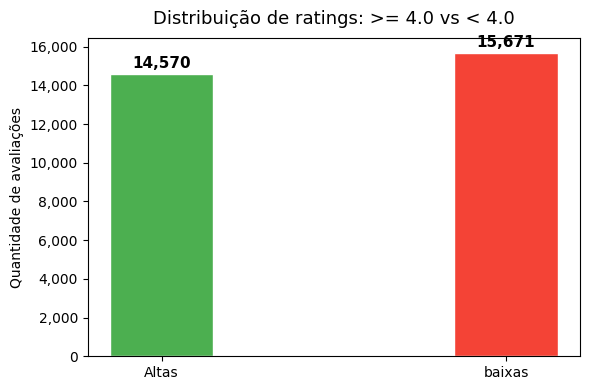

In [36]:
altas  = (df["rating"] >= 4.0).sum()
baixas = (df["rating"] < 4.0).sum()

print(f"Ratings >= 4.0 : {altas:,}  ({altas/len(df)*100:.1f}%)")
print(f"Ratings <  4.0 : {baixas:,}  ({baixas/len(df)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Altas", "baixas"], [altas, baixas], color=["#4CAF50", "#F44336"], width=0.3, edgecolor="white")

for rect, val in zip(ax.patches, [altas, baixas]):
    ax.text(rect.get_x() + rect.get_width() / 2, rect.get_height() + len(df) * 0.005,
            f"{val:,}", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Distribuição de ratings: >= 4.0 vs < 4.0", fontsize=13, pad=10)
ax.set_ylabel("Quantidade de avaliações")
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.show()

## 7 — Usuários com TODAS as notas acima de 4.0

In [37]:
# Para cada usuário, pega a menor nota dada
nota_minima = df.groupby("userId")["rating"].min()

# Usuários onde ATÉ a menor nota é > 4.0
so_altas = nota_minima[nota_minima > 4.0].reset_index()
so_altas.columns = ["userId", "nota_minima"]

# Adiciona total de avaliações e média para contexto
so_altas = so_altas.merge(
    df.groupby("userId").agg(total_avaliacoes=("rating", "count"), media=("rating", "mean")).reset_index(),
    on="userId"
).sort_values("total_avaliacoes", ascending=False)
so_altas["media"] = so_altas["media"].round(2)

print("=" * 60)
print("  Usuários com TODAS as notas acima de 4.0 (testing.csv)")
print("=" * 60)
print(f"  Total: {len(so_altas)} usuário(s)\n")

print(f"  {'userId':>8}  {'total avaliações':>18}  {'menor nota':>12}  {'média':>7}")
print(f"  {'-'*8}  {'-'*18}  {'-'*12}  {'-'*7}")
for _, row in so_altas.iterrows():
    print(f"  {int(row['userId']):>8}  {int(row['total_avaliacoes']):>18,}  {row['nota_minima']:>12.1f}  {row['media']:>7.2f}")

print("=" * 60)

  Usuários com TODAS as notas acima de 4.0 (testing.csv)
  Total: 3 usuário(s)

    userId    total avaliações    menor nota    média
  --------  ------------------  ------------  -------
       515                   8           4.5     4.94
       251                   7           4.5     4.93
        53                   6           5.0     5.00
